In [108]:
%load_ext autoreload
%autoreload 2

In [112]:
import pandas as pd
from concurrent.futures import ProcessPoolExecutor, as_completed
from tqdm import tqdm
import protfasta
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [109]:
import time_normalization_helpers

# Reading in DBDs from CisBP

In [4]:
DBD_sql_dump = pd.read_csv("../../../data/DBD_sql_dump.csv", nrows = 5, index_col = 0)
DBD_sql_dump

,PFeature_ID,Protein_ID,Domain_ID,ProtFeature_FromPos,ProtFeature_ToPos,ProtFeature_Sequence,Domain_Name,Pfam_Name,Pfam_DBID,Inter_DBID,Domain_Type
0,PF000001_2.00,P000002_2.00,D08_2.00,46,137,PTSRLQAPRFPLLKVIPEWVINHFGRNIVGSIKLEAPNGNIYDVGV...,B3,B3,PF02362,IPR003340,DBD
1,PF000002_2.00,P000002_2.00,D08_2.00,194,293,LVVLMKKSNVNHNFTLIIRKDYAREYFPPKNTTIILQLPGKSKHWN...,B3,B3,PF02362,IPR003340,DBD
2,PF000003_2.00,P000002_2.00,D01_2.00,327,442,KEEPIIDESTKTALTPRVKEEPTIDGTGVRHISNHIFSIHCPCQIH...,ABF1,BAF1_ABF1,PF04684,IPR006774,DBD
3,PF000004_2.00,P000002_2.00,D08_2.00,507,611,VHKRGSPSPVFSSQYISRYLAEKYATGLTGVRGRRGAISLLLERDG...,B3,B3,PF02362,IPR003340,DBD
4,PF000005_2.00,P000003_2.00,D08_2.00,231,323,QAEKKAILPKPKEEYEYDNDGKKKKNKESHGLEVMAYDRTGEPYNL...,B3,B3,PF02362,IPR003340,DBD


In [5]:
# Saving unique DBDs
unique_DBDs = DBD_sql_dump[["ProtFeature_Sequence"]].drop_duplicates()
unique_DBDs

,ProtFeature_Sequence
0,PTSRLQAPRFPLLKVIPEWVINHFGRNIVGSIKLEAPNGNIYDVGV...
1,LVVLMKKSNVNHNFTLIIRKDYAREYFPPKNTTIILQLPGKSKHWN...
2,KEEPIIDESTKTALTPRVKEEPTIDGTGVRHISNHIFSIHCPCQIH...
3,VHKRGSPSPVFSSQYISRYLAEKYATGLTGVRGRRGAISLLLERDG...
4,QAEKKAILPKPKEEYEYDNDGKKKKNKESHGLEVMAYDRTGEPYNL...


In [7]:
yeast_TFs = protfasta.read_fasta("../../../data/yeast_TFs.fasta")
yeast_TFs = pd.DataFrame({"id" : yeast_TFs.keys(), "seq" : yeast_TFs.values()})
yeast_TFs

,id,seq
0,sp|O14467|MBF1_YEAST Multiprotein-bridging fac...,MSDWDTNTIIGSRARAGGSGPRANVARSQGQINAARRQGLVVSVDK...
1,sp|O93958|MATA2_YARLL Mating-type protein A2 O...,MENTILHIHSFQLPQTEQPYPEAMLFDRDTSDSRTVLTQKPNGLEI...
2,sp|P03069|GCN4_YEAST General control transcrip...,MSEYQPSLFALNPMGFSPLDGSKSTNENVSASTSTAKPMVGQLIFD...
3,sp|P04386|GAL4_YEAST Regulatory protein GAL4 O...,MKLLSSIEQACDICRLKKLKCSKEKPKCAKCLKNNWECRYSPKTKR...
4,sp|P04387|GAL80_YEAST Galactose/lactose metabo...,MDYNKRSSVSTVPNAAPIRVGFVGLNAAKGWAIKTHYPAILQLSSQ...
...,...,...
242,sp|Q707Y3|MATA1_YARLL Mating-type protein A1 O...,MPSRTPTDIWRCQRLILAARKGETTCQALHEQSIEISSSLKWFEEI...
243,sp|Q707Y6|MATA1_PICAN Mating-type protein A1 O...,MQFTILNEPSLDSQRREGDLASENYVFGDIRKEGVRILEDSLRSER...
244,sp|Q708A1|MATA1_NAKDE Mating-type protein A1 O...,MNVQEIHNIREACITILSGTKHNSVLFEPCDKFDEVINSLDIDPDS...
245,sp|Q9HG12|MATA1_KLULA Mating-type protein A1 O...,MCDNDMADIQSKLSSFCEEIRALALKEGYNLEGDKSPSSKPYFMSW...


In [9]:
# 1. Load your data

# CisBP DBD table
dbd_df = pd.read_csv("../../../data/DBD_sql_dump.csv", index_col = 0)
display(dbd_df)

# Yeast TF sequences table
yeast_TFs = protfasta.read_fasta("../../../data/yeast_TFs.fasta")
yeast_TFs = pd.DataFrame({"id" : yeast_TFs.keys(), "seq" : yeast_TFs.values()})
yeast_TFs

,PFeature_ID,Protein_ID,Domain_ID,ProtFeature_FromPos,ProtFeature_ToPos,ProtFeature_Sequence,Domain_Name,Pfam_Name,Pfam_DBID,Inter_DBID,Domain_Type
0,PF000001_2.00,P000002_2.00,D08_2.00,46,137,PTSRLQAPRFPLLKVIPEWVINHFGRNIVGSIKLEAPNGNIYDVGV...,B3,B3,PF02362,IPR003340,DBD
1,PF000002_2.00,P000002_2.00,D08_2.00,194,293,LVVLMKKSNVNHNFTLIIRKDYAREYFPPKNTTIILQLPGKSKHWN...,B3,B3,PF02362,IPR003340,DBD
2,PF000003_2.00,P000002_2.00,D01_2.00,327,442,KEEPIIDESTKTALTPRVKEEPTIDGTGVRHISNHIFSIHCPCQIH...,ABF1,BAF1_ABF1,PF04684,IPR006774,DBD
3,PF000004_2.00,P000002_2.00,D08_2.00,507,611,VHKRGSPSPVFSSQYISRYLAEKYATGLTGVRGRRGAISLLLERDG...,B3,B3,PF02362,IPR003340,DBD
4,PF000005_2.00,P000003_2.00,D08_2.00,231,323,QAEKKAILPKPKEEYEYDNDGKKKKNKESHGLEVMAYDRTGEPYNL...,B3,B3,PF02362,IPR003340,DBD
...,...,...,...,...,...,...,...,...,...,...,...
993361,PF993362_2.00,P436367_2.00,D89_2.00,25,63,QACDRCRIKKIKCDGTLPSCTNCSKIGFVCKISDRLTRS,Zinc cluster,Zn_clus,PF00172,IPR001138,DBD
993362,PF993363_2.00,P436368_2.00,D89_2.00,14,51,YNCGPCKRQKIKCDTNLPCSNCVKYKRVAKCYQEPPNP,Zinc cluster,Zn_clus,PF00172,IPR001138,DBD
993363,PF993364_2.00,P436369_2.00,D89_2.00,67,107,KSCTRCRKHKIKCDFQERKPNACSMCSRKNVQCELEIIIPM,Zinc cluster,Zn_clus,PF00172,IPR001138,DBD
993364,PF993365_2.00,P436370_2.00,D89_2.00,303,323,YTVGKPCSRCAKFNKKCEDAL,Zinc cluster,Zn_clus,PF00172,IPR001138,DBD


,id,seq
0,sp|O14467|MBF1_YEAST Multiprotein-bridging fac...,MSDWDTNTIIGSRARAGGSGPRANVARSQGQINAARRQGLVVSVDK...
1,sp|O93958|MATA2_YARLL Mating-type protein A2 O...,MENTILHIHSFQLPQTEQPYPEAMLFDRDTSDSRTVLTQKPNGLEI...
2,sp|P03069|GCN4_YEAST General control transcrip...,MSEYQPSLFALNPMGFSPLDGSKSTNENVSASTSTAKPMVGQLIFD...
3,sp|P04386|GAL4_YEAST Regulatory protein GAL4 O...,MKLLSSIEQACDICRLKKLKCSKEKPKCAKCLKNNWECRYSPKTKR...
4,sp|P04387|GAL80_YEAST Galactose/lactose metabo...,MDYNKRSSVSTVPNAAPIRVGFVGLNAAKGWAIKTHYPAILQLSSQ...
...,...,...
242,sp|Q707Y3|MATA1_YARLL Mating-type protein A1 O...,MPSRTPTDIWRCQRLILAARKGETTCQALHEQSIEISSSLKWFEEI...
243,sp|Q707Y6|MATA1_PICAN Mating-type protein A1 O...,MQFTILNEPSLDSQRREGDLASENYVFGDIRKEGVRILEDSLRSER...
244,sp|Q708A1|MATA1_NAKDE Mating-type protein A1 O...,MNVQEIHNIREACITILSGTKHNSVLFEPCDKFDEVINSLDIDPDS...
245,sp|Q9HG12|MATA1_KLULA Mating-type protein A1 O...,MCDNDMADIQSKLSSFCEEIRALALKEGYNLEGDKSPSSKPYFMSW...


In [18]:
! pip install pyahocorasick

Defaulting to user installation because normal site-packages is not writeable
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 113.9/113.9 kB 3.0 MB/s eta 0:00:0000:01


In [19]:
import pandas as pd
import ahocorasick
from tqdm import tqdm

In [29]:
# -----------------------------
# 1. Build Aho–Corasick automaton
# -----------------------------
print("Building automaton...")

A = ahocorasick.Automaton()

for row in tqdm(dbd_df.itertuples(index=False), total=len(dbd_df)):
    dbd_seq = row.ProtFeature_Sequence
    
    # skip empty or NaN sequences
    if not isinstance(dbd_seq, str) or not dbd_seq:
        continue

    A.add_word(dbd_seq, (
        row.PFeature_ID,
        row.Domain_Name,
        dbd_seq
    ))

A.make_automaton()

print(f"Automaton built with {len(A)} patterns")

# -----------------------------
# 2. Scan TF sequences
# -----------------------------
print("Scanning TFs...")

matches = []

for tf_row in tqdm(yeast_TFs.itertuples(index=False), total=len(yeast_TFs)):
    tf_id = tf_row.id
    tf_seq = tf_row.seq

    if not isinstance(tf_seq, str) or not tf_seq:
        continue

    for end_idx, (dbd_id, domain_name, dbd_seq) in A.iter(tf_seq):
        start_idx = end_idx - len(dbd_seq) + 1

        matches.append((
            tf_id,
            dbd_id,
            domain_name,
            start_idx + 1,   # 1-based
            end_idx + 1,
            dbd_seq,
            tf_row.seq
        ))

# -----------------------------
# 3. Convert to DataFrame
# -----------------------------
print("Converting to DataFrame...")

matches_df = pd.DataFrame(matches, columns=[
    "TF_id",
    "DBD_id",
    "Domain_Name",
    "TF_start",
    "TF_end",
    "DBD_seq",
    "TF_seq"
])

print(f"Done. Found {len(matches_df)} matches.")

Building automaton...


100%|██████████| 993366/993366 [00:03<00:00, 314936.01it/s]


Automaton built with 564305 patterns
Scanning TFs...


100%|██████████| 247/247 [00:00<00:00, 12534.09it/s]

Converting to DataFrame...
Done. Found 289 matches.


In [31]:
matches_df

,TF_id,DBD_id,Domain_Name,TF_start,TF_end,DBD_seq,TF_seq
0,sp|P03069|GCN4_YEAST General control transcrip...,PF097246_2.00,bZIP,227,280,PAALKRARNTEAARRSRARKLQRMKQLEDKVEELLSKNYHLENEVA...,MSEYQPSLFALNPMGFSPLDGSKSTNENVSASTSTAKPMVGQLIFD...
1,sp|P03069|GCN4_YEAST General control transcrip...,PF090379_2.00,bZIP,228,280,AALKRARNTEAARRSRARKLQRMKQLEDKVEELLSKNYHLENEVAR...,MSEYQPSLFALNPMGFSPLDGSKSTNENVSASTSTAKPMVGQLIFD...
2,sp|P04386|GAL4_YEAST Regulatory protein GAL4 O...,PF991824_2.00,Zinc cluster,9,47,QACDICRLKKLKCSKEKPKCAKCLKNNWECRYSPKTKRS,MKLLSSIEQACDICRLKKLKCSKEKPKCAKCLKNNWECRYSPKTKR...
3,sp|P05085|ARGR2_YEAST Arginine metabolism regu...,PF991796_2.00,Zinc cluster,19,58,TGCWTCRGRKVKCDLRHPHCQRCEKSNLPCGGYDIKLRWS,MGISSKNGPKKMGRAKTFTGCWTCRGRKVKCDLRHPHCQRCEKSNL...
4,sp|P06774|HAP2_YEAST Transcriptional activator...,PF684167_2.00,CBF/NF-Y,159,214,QPFYVNAKQYYRILKRRYARAKLEEKLRISRERKPYLHESRHKHAM...,MSADETDAKFHPLETDLQSDTAAATSTAAASRSPSLQEKPIEMPLD...
...,...,...,...,...,...,...,...
284,sp|Q12531|YP015_YEAST Zinc finger protein YPR0...,PF625871_2.00,C2H2 ZF,185,207,KQCPICGKVCSRPSTLRTHYLIH,MWRTKTLESMLCSPMKCSSSNIGGSYAQSSKEVSNTTKREVHLPPC...
285,sp|Q12531|YP015_YEAST Zinc finger protein YPR0...,PF625860_2.00,C2H2 ZF,213,237,FKCTWEHCNKSFNVKSNMLRHLRTH,MWRTKTLESMLCSPMKCSSSNIGGSYAQSSKEVSNTTKREVHLPPC...
286,sp|Q12753|HAA1_YEAST Transcriptional activator...,PF688249_2.00,Copper fist,2,40,VLINGIKYACERCIRGHRVTTCNHTDQPLMMIKPKGRPS,MVLINGIKYACERCIRGHRVTTCNHTDQPLMMIKPKGRPSTTCDYC...
287,sp|Q707Y6|MATA1_PICAN Mating-type protein A1 O...,PF761224_2.00,Homeodomain,123,179,KKKRRHIPESSKELLEKAFKVKRFPNSKERERIARECGISPLQVRV...,MQFTILNEPSLDSQRREGDLASENYVFGDIRKEGVRILEDSLRSER...


In [33]:
from collections import defaultdict
import pandas as pd

merged_results = []

# group everything by TF_id
groups = defaultdict(list)
tf_seq_map = {}

for row in matches_df.itertuples(index=False):
    groups[row.TF_id].append((row.TF_start, row.TF_end))
    
    # store TF_seq once per TF
    if row.TF_id not in tf_seq_map:
        tf_seq_map[row.TF_id] = row.TF_seq

# merge intervals per TF
for tf_id, intervals in groups.items():
    intervals.sort()
    tf_seq = tf_seq_map[tf_id]
    
    merged = []
    
    for start, end in intervals:
        if not merged:
            merged.append([start, end])
        else:
            if start <= merged[-1][1]:
                merged[-1][1] = max(merged[-1][1], end)
            else:
                merged.append([start, end])
    
    # attach TF_seq to each merged interval
    for start, end in merged:
        merged_results.append((tf_id, start, end, tf_seq))

# final dataframe
merged_df = pd.DataFrame(
    merged_results,
    columns=["TF_id", "TF_start", "TF_end", "TF_seq"]
)

merged_df

,TF_id,TF_start,TF_end,TF_seq
0,sp|P03069|GCN4_YEAST General control transcrip...,227,280,MSEYQPSLFALNPMGFSPLDGSKSTNENVSASTSTAKPMVGQLIFD...
1,sp|P04386|GAL4_YEAST Regulatory protein GAL4 O...,9,47,MKLLSSIEQACDICRLKKLKCSKEKPKCAKCLKNNWECRYSPKTKR...
2,sp|P05085|ARGR2_YEAST Arginine metabolism regu...,19,58,MGISSKNGPKKMGRAKTFTGCWTCRGRKVKCDLRHPHCQRCEKSNL...
3,sp|P06774|HAP2_YEAST Transcriptional activator...,159,214,MSADETDAKFHPLETDLQSDTAAATSTAAASRSPSLQEKPIEMPLD...
4,sp|P06782|SNF1_YEAST Carbon catabolite-derepre...,1,633,MSSNNNTNTAPANANSSHHHHHHHHHHHHHGHGGSNSTLNNPKSSL...
...,...,...,...,...
269,sp|Q12531|YP015_YEAST Zinc finger protein YPR0...,185,207,MWRTKTLESMLCSPMKCSSSNIGGSYAQSSKEVSNTTKREVHLPPC...
270,sp|Q12531|YP015_YEAST Zinc finger protein YPR0...,213,237,MWRTKTLESMLCSPMKCSSSNIGGSYAQSSKEVSNTTKREVHLPPC...
271,sp|Q12753|HAA1_YEAST Transcriptional activator...,2,40,MVLINGIKYACERCIRGHRVTTCNHTDQPLMMIKPKGRPSTTCDYC...
272,sp|Q707Y6|MATA1_PICAN Mating-type protein A1 O...,123,179,MQFTILNEPSLDSQRREGDLASENYVFGDIRKEGVRILEDSLRSER...


In [34]:
merged_df = merged_df.rename(columns = {"TF_id" : "id", "TF_start" : "DBD_start", "TF_end" : "DBD_end"})
merged_df

,id,DBD_start,DBD_end,TF_seq
0,sp|P03069|GCN4_YEAST General control transcrip...,227,280,MSEYQPSLFALNPMGFSPLDGSKSTNENVSASTSTAKPMVGQLIFD...
1,sp|P04386|GAL4_YEAST Regulatory protein GAL4 O...,9,47,MKLLSSIEQACDICRLKKLKCSKEKPKCAKCLKNNWECRYSPKTKR...
2,sp|P05085|ARGR2_YEAST Arginine metabolism regu...,19,58,MGISSKNGPKKMGRAKTFTGCWTCRGRKVKCDLRHPHCQRCEKSNL...
3,sp|P06774|HAP2_YEAST Transcriptional activator...,159,214,MSADETDAKFHPLETDLQSDTAAATSTAAASRSPSLQEKPIEMPLD...
4,sp|P06782|SNF1_YEAST Carbon catabolite-derepre...,1,633,MSSNNNTNTAPANANSSHHHHHHHHHHHHHGHGGSNSTLNNPKSSL...
...,...,...,...,...
269,sp|Q12531|YP015_YEAST Zinc finger protein YPR0...,185,207,MWRTKTLESMLCSPMKCSSSNIGGSYAQSSKEVSNTTKREVHLPPC...
270,sp|Q12531|YP015_YEAST Zinc finger protein YPR0...,213,237,MWRTKTLESMLCSPMKCSSSNIGGSYAQSSKEVSNTTKREVHLPPC...
271,sp|Q12753|HAA1_YEAST Transcriptional activator...,2,40,MVLINGIKYACERCIRGHRVTTCNHTDQPLMMIKPKGRPSTTCDYC...
272,sp|Q707Y6|MATA1_PICAN Mating-type protein A1 O...,123,179,MQFTILNEPSLDSQRREGDLASENYVFGDIRKEGVRILEDSLRSER...


In [141]:
merged_df["DBD_len"] = merged_df["DBD_end"] - merged_df["DBD_start"]
merged_df

,id,DBD_start,DBD_end,TF_seq,DBD_seq,DBD_len
0,sp|P03069|GCN4_YEAST General control transcrip...,227,280,MSEYQPSLFALNPMGFSPLDGSKSTNENVSASTSTAKPMVGQLIFD...,PAALKRARNTEAARRSRARKLQRMKQLEDKVEELLSKNYHLENEVA...,53
1,sp|P04386|GAL4_YEAST Regulatory protein GAL4 O...,9,47,MKLLSSIEQACDICRLKKLKCSKEKPKCAKCLKNNWECRYSPKTKR...,QACDICRLKKLKCSKEKPKCAKCLKNNWECRYSPKTKRS,38
2,sp|P05085|ARGR2_YEAST Arginine metabolism regu...,19,58,MGISSKNGPKKMGRAKTFTGCWTCRGRKVKCDLRHPHCQRCEKSNL...,TGCWTCRGRKVKCDLRHPHCQRCEKSNLPCGGYDIKLRWS,39
3,sp|P06774|HAP2_YEAST Transcriptional activator...,159,214,MSADETDAKFHPLETDLQSDTAAATSTAAASRSPSLQEKPIEMPLD...,QPFYVNAKQYYRILKRRYARAKLEEKLRISRERKPYLHESRHKHAM...,55
4,sp|P06782|SNF1_YEAST Carbon catabolite-derepre...,1,633,MSSNNNTNTAPANANSSHHHHHHHHHHHHHGHGGSNSTLNNPKSSL...,MSSNNNTNTAPANANSSHHHHHHHHHHHHHGHGGSNSTLNNPKSSL...,632
...,...,...,...,...,...,...
269,sp|Q12531|YP015_YEAST Zinc finger protein YPR0...,185,207,MWRTKTLESMLCSPMKCSSSNIGGSYAQSSKEVSNTTKREVHLPPC...,KQCPICGKVCSRPSTLRTHYLIH,22
270,sp|Q12531|YP015_YEAST Zinc finger protein YPR0...,213,237,MWRTKTLESMLCSPMKCSSSNIGGSYAQSSKEVSNTTKREVHLPPC...,FKCTWEHCNKSFNVKSNMLRHLRTH,24
271,sp|Q12753|HAA1_YEAST Transcriptional activator...,2,40,MVLINGIKYACERCIRGHRVTTCNHTDQPLMMIKPKGRPSTTCDYC...,VLINGIKYACERCIRGHRVTTCNHTDQPLMMIKPKGRPS,38
272,sp|Q707Y6|MATA1_PICAN Mating-type protein A1 O...,123,179,MQFTILNEPSLDSQRREGDLASENYVFGDIRKEGVRILEDSLRSER...,KKKRRHIPESSKELLEKAFKVKRFPNSKERERIARECGISPLQVRV...,56


/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='DBD_len', ylabel='Count'>

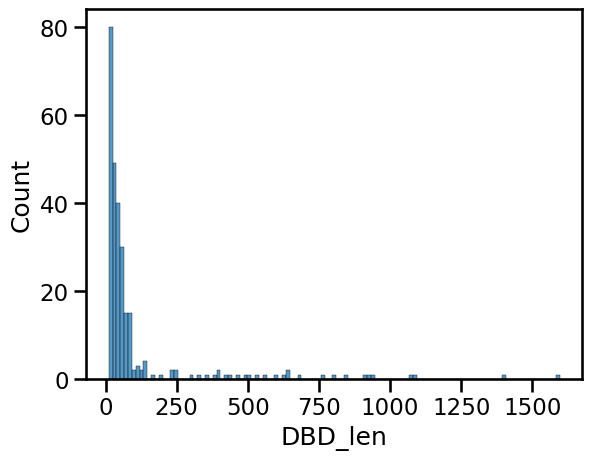

In [142]:
sns.histplot(data = merged_df, x = "DBD_len")

In [35]:
merged_df["DBD_seq"] = merged_df.apply(
    lambda x: x.TF_seq[x.DBD_start - 1 : x.DBD_end],
    axis=1
)
merged_df

,id,DBD_start,DBD_end,TF_seq,DBD_seq
0,sp|P03069|GCN4_YEAST General control transcrip...,227,280,MSEYQPSLFALNPMGFSPLDGSKSTNENVSASTSTAKPMVGQLIFD...,PAALKRARNTEAARRSRARKLQRMKQLEDKVEELLSKNYHLENEVA...
1,sp|P04386|GAL4_YEAST Regulatory protein GAL4 O...,9,47,MKLLSSIEQACDICRLKKLKCSKEKPKCAKCLKNNWECRYSPKTKR...,QACDICRLKKLKCSKEKPKCAKCLKNNWECRYSPKTKRS
2,sp|P05085|ARGR2_YEAST Arginine metabolism regu...,19,58,MGISSKNGPKKMGRAKTFTGCWTCRGRKVKCDLRHPHCQRCEKSNL...,TGCWTCRGRKVKCDLRHPHCQRCEKSNLPCGGYDIKLRWS
3,sp|P06774|HAP2_YEAST Transcriptional activator...,159,214,MSADETDAKFHPLETDLQSDTAAATSTAAASRSPSLQEKPIEMPLD...,QPFYVNAKQYYRILKRRYARAKLEEKLRISRERKPYLHESRHKHAM...
4,sp|P06782|SNF1_YEAST Carbon catabolite-derepre...,1,633,MSSNNNTNTAPANANSSHHHHHHHHHHHHHGHGGSNSTLNNPKSSL...,MSSNNNTNTAPANANSSHHHHHHHHHHHHHGHGGSNSTLNNPKSSL...
...,...,...,...,...,...
269,sp|Q12531|YP015_YEAST Zinc finger protein YPR0...,185,207,MWRTKTLESMLCSPMKCSSSNIGGSYAQSSKEVSNTTKREVHLPPC...,KQCPICGKVCSRPSTLRTHYLIH
270,sp|Q12531|YP015_YEAST Zinc finger protein YPR0...,213,237,MWRTKTLESMLCSPMKCSSSNIGGSYAQSSKEVSNTTKREVHLPPC...,FKCTWEHCNKSFNVKSNMLRHLRTH
271,sp|Q12753|HAA1_YEAST Transcriptional activator...,2,40,MVLINGIKYACERCIRGHRVTTCNHTDQPLMMIKPKGRPSTTCDYC...,VLINGIKYACERCIRGHRVTTCNHTDQPLMMIKPKGRPS
272,sp|Q707Y6|MATA1_PICAN Mating-type protein A1 O...,123,179,MQFTILNEPSLDSQRREGDLASENYVFGDIRKEGVRILEDSLRSER...,KKKRRHIPESSKELLEKAFKVKRFPNSKERERIARECGISPLQVRV...


In [147]:
activities = pd.read_csv("../../../output/ChopTFs_pipeline/trebl_experiment_activities_per_AD.csv", index_col = 0)
activities

,AD_protein,rep,time,activity_simple_mean,activity_simple_std,activity_directional_mean,activity_directional_std,rep_count,activity_simple_cv,activity_directional_cv
2,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,0,-0.899670,0.077177,-0.899670,0.077177,2,-0.085783,-0.085783
3,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,2,-0.728546,0.257942,-0.738533,0.244102,3,-0.354050,-0.330522
4,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,5,-0.538035,0.271745,-0.542113,0.321389,3,-0.505070,-0.592845
5,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,10,-0.684608,0.132290,-0.840621,0.337376,2,-0.193235,-0.401341
6,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,15,-0.544068,0.187561,-0.581385,0.134787,2,-0.344738,-0.231838
...,...,...,...,...,...,...,...,...,...,...
472381,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,4,60,0.051218,0.341356,0.012307,0.337090,4,6.664764,27.389808
472384,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,2,5,-0.935786,0.471961,-0.935786,0.471961,2,-0.504346,-0.504346
472387,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,2,20,-0.411954,0.582591,-0.430849,0.609312,2,-1.414214,-1.414214
472388,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,2,30,-0.471889,0.844041,-0.505362,0.891380,2,-1.788645,-1.763844


In [159]:
import ahocorasick
import numpy as np

# --- Build automaton with DBD sequences ---
A = ahocorasick.Automaton()

for row in merged_df.itertuples(index=False):
    # store tuple: (TF_id, DBD_seq)
    A.add_word(row.DBD_seq, (row.id, row.DBD_seq))

A.make_automaton()

# --- Search AD sequences and compute overlap fraction ---
overlap_results = []
ad_df = activities.copy()

for row in ad_df.itertuples(index=False):
    ad_seq = row.AD_protein
    ad_len = len(ad_seq)
    
    # Create a boolean mask for AD residues covered by any DBD
    covered = np.zeros(ad_len, dtype=bool)
    
    for end_idx, (tf_id, dbd_seq) in A.iter(ad_seq):
        pattern_len = len(dbd_seq)
        start_idx = end_idx - pattern_len + 1
        
        # mark positions as covered
        covered[start_idx:end_idx+1] = True
    
    # fraction of AD residues covered by any DBD
    overlap_frac = covered.sum() / ad_len
    overlap_results.append(overlap_frac)

ad_df["dbd_overlap_frac"] = overlap_results
ad_df["dbd_overlap_flag"] = ad_df["dbd_overlap_frac"] >= 0.5

In [160]:
ad_df

,AD_protein,rep,time,activity_simple_mean,activity_simple_std,activity_directional_mean,activity_directional_std,rep_count,activity_simple_cv,activity_directional_cv,dbd_overlap_frac,dbd_overlap_flag
2,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,0,-0.899670,0.077177,-0.899670,0.077177,2,-0.085783,-0.085783,0.0,False
3,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,2,-0.728546,0.257942,-0.738533,0.244102,3,-0.354050,-0.330522,0.0,False
4,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,5,-0.538035,0.271745,-0.542113,0.321389,3,-0.505070,-0.592845,0.0,False
5,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,10,-0.684608,0.132290,-0.840621,0.337376,2,-0.193235,-0.401341,0.0,False
6,AAAAAASSSLGDNKDEDKPHDSLGIQLDDNSQNSMVPAPS,2,15,-0.544068,0.187561,-0.581385,0.134787,2,-0.344738,-0.231838,0.0,False
...,...,...,...,...,...,...,...,...,...,...,...,...
472381,YYWKTLNFTTPMYGADTPGSIFPEGLNVWNVAKLPNILDH,4,60,0.051218,0.341356,0.012307,0.337090,4,6.664764,27.389808,0.0,False
472384,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,2,5,-0.935786,0.471961,-0.935786,0.471961,2,-0.504346,-0.504346,0.0,False
472387,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,2,20,-0.411954,0.582591,-0.430849,0.609312,2,-1.414214,-1.414214,0.0,False
472388,YYYVKYPHAIDAIKWKVHQVVQRLKDDLDKNSEPNGYMCP,2,30,-0.471889,0.844041,-0.505362,0.891380,2,-1.788645,-1.763844,0.0,False


In [161]:
sum(ad_df["dbd_overlap_flag"])

4187

In [162]:
ad_df[ad_df["dbd_overlap_flag"]]

,AD_protein,rep,time,activity_simple_mean,activity_simple_std,activity_directional_mean,activity_directional_std,rep_count,activity_simple_cv,activity_directional_cv,dbd_overlap_frac,dbd_overlap_flag
3226,AEHLARHIRKHTGEKPFQCPACLKFFSRVDNLKQHRESVH,2,10,-0.639377,0.478495,-0.639377,0.478495,2,-0.748377,-0.748377,0.600,True
3228,AEHLARHIRKHTGEKPFQCPACLKFFSRVDNLKQHRESVH,2,40,-0.712984,0.445540,-0.712984,0.445540,2,-0.624894,-0.624894,0.600,True
3229,AEHLARHIRKHTGEKPFQCPACLKFFSRVDNLKQHRESVH,2,50,-0.113622,1.012127,-0.113622,1.012127,2,-8.907852,-8.907852,0.600,True
3231,AEHLARHIRKHTGEKPFQCPACLKFFSRVDNLKQHRESVH,3,0,-0.729319,0.042920,-0.729319,0.042920,2,-0.058849,-0.058849,0.600,True
3233,AEHLARHIRKHTGEKPFQCPACLKFFSRVDNLKQHRESVH,3,5,-1.073064,0.529049,-1.065167,0.517881,2,-0.493026,-0.486197,0.600,True
...,...,...,...,...,...,...,...,...,...,...,...,...
457807,WKTDTRISSTKLRKQCPVCGKICSRPSTLKTHYLIHTGDT,3,10,-0.535019,0.756631,-0.559345,0.791033,2,-1.414214,-1.414214,0.575,True
457821,WKTDTRISSTKLRKQCPVCGKICSRPSTLKTHYLIHTGDT,4,40,-0.309225,0.863031,-0.459740,0.650171,2,-2.790947,-1.414214,0.575,True
471362,YVKEMPDKTFECLFPGCTKTFKRRYNIRSHIQTHLEDRPY,2,40,-0.849485,0.212860,-0.849485,0.212860,2,-0.250576,-0.250576,0.625,True
471363,YVKEMPDKTFECLFPGCTKTFKRRYNIRSHIQTHLEDRPY,2,50,-0.759257,0.275751,-0.977121,0.393365,2,-0.363186,-0.402576,0.625,True


In [163]:
ad_df[ad_df["dbd_overlap_flag"]]["AD_protein"].value_counts()

AD_protein
LKRHQHSHTREKPYLCIFCGRCFARRDLVLRHQQKLHAAL    30
MSSSGVYTCNSCVLTFDSSDEQRAHMKSDWHRYNLKRRVA    30
PFRCDTCHRGFHRLEHKKRHLRTHTGEKPHHCAFPGCGKS    30
PFHCHICPKSFKRSEHLKRHVRSVHSNERPFACHICDKKF    30
TPSGKLRSFVCEVCTRAFARQEHLKRHYRSHTNEKPYPCG    30
                                            ..
YVKEMPDKTFECLFPGCTKTFKRRYNIRSHIQTHLEDRPY     3
HIRSVHSTERPFACMFCEKKFSRSDNLSQHLKTHKKHGDF     2
GEKPFQCNICLKFFSRIDNLRQHQSSVHSDVDLMSLRRLQ     2
ANVPVCKNCLTSTTPLWRRDEHGAMLCNACGLFLKLHGKP     2
WKTDTRISSTKLRKQCPVCGKICSRPSTLKTHYLIHTGDT     2
Name: count, Length: 173, dtype: int64

In [164]:
len(ad_df[ad_df["dbd_overlap_flag"]]["AD_protein"].value_counts())

173

# Where do DBDs lie on distribution?

In [156]:
activities_per_bc = pd.read_csv("../../../output/ChopTFs_pipeline/trebl_experiment_activities_per_barcode.csv", index_col = 0)
activities_per_bc

,AD,AD_end,AD_BC,RPTR_BC,count_simple_AD,count_directional_AD,rep,time,count_simple_RT,count_directional_RT,activity_simple,activity_directional,AD_protein
0,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,177.0,175.0,2,0,11.0,11.0,-1.206581,-1.201645,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
1,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,186.0,182.0,2,2,14.0,14.0,-1.123385,-1.113943,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
2,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,166.0,164.0,2,5,10.0,8.0,-1.220108,-1.311754,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
3,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,232.0,231.0,2,10,34.0,33.0,-0.834009,-0.845098,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
4,AAAAATTCATTCTCTTTGGCTAAATCTGAAGAATCTACTAATGATT...,TTCTGAGAATCCATTGAATGAAGCTCAACAACAAGATCAA,ATAACCAATGG,TGAGAGAAAATCTA,243.0,241.0,2,15,70.0,65.0,-0.540508,-0.569104,KNSFSLAKSEESTNDYAMANYLNNTPISENPLNEAQQQDQ
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1827292,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,74.0,73.0,4,20,10.0,9.0,-0.869232,-0.909080,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827293,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,87.0,86.0,4,30,16.0,14.0,-0.735399,-0.788370,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827294,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,96.0,95.0,4,40,16.0,16.0,-0.778151,-0.773604,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR
1827295,TTTGTTTGTGATTATTGTGGTAAGAGATTTACTCAAGGTGGTAATT...,ACCATATTCTTGTGATATTTGTGATAAGAAATTCTCTAGA,TACAACTTTAT,TTCCGCACTAGAAA,108.0,108.0,4,50,28.0,27.0,-0.586266,-0.602060,FVCDYCGKRFTQGGNLRTHERLHTGEKPYSCDICDKKFSR


In [165]:
dbd_tiles = ad_df[ad_df["dbd_overlap_flag"]]
dbd_tiles

,AD_protein,rep,time,activity_simple_mean,activity_simple_std,activity_directional_mean,activity_directional_std,rep_count,activity_simple_cv,activity_directional_cv,dbd_overlap_frac,dbd_overlap_flag
3226,AEHLARHIRKHTGEKPFQCPACLKFFSRVDNLKQHRESVH,2,10,-0.639377,0.478495,-0.639377,0.478495,2,-0.748377,-0.748377,0.600,True
3228,AEHLARHIRKHTGEKPFQCPACLKFFSRVDNLKQHRESVH,2,40,-0.712984,0.445540,-0.712984,0.445540,2,-0.624894,-0.624894,0.600,True
3229,AEHLARHIRKHTGEKPFQCPACLKFFSRVDNLKQHRESVH,2,50,-0.113622,1.012127,-0.113622,1.012127,2,-8.907852,-8.907852,0.600,True
3231,AEHLARHIRKHTGEKPFQCPACLKFFSRVDNLKQHRESVH,3,0,-0.729319,0.042920,-0.729319,0.042920,2,-0.058849,-0.058849,0.600,True
3233,AEHLARHIRKHTGEKPFQCPACLKFFSRVDNLKQHRESVH,3,5,-1.073064,0.529049,-1.065167,0.517881,2,-0.493026,-0.486197,0.600,True
...,...,...,...,...,...,...,...,...,...,...,...,...
457807,WKTDTRISSTKLRKQCPVCGKICSRPSTLKTHYLIHTGDT,3,10,-0.535019,0.756631,-0.559345,0.791033,2,-1.414214,-1.414214,0.575,True
457821,WKTDTRISSTKLRKQCPVCGKICSRPSTLKTHYLIHTGDT,4,40,-0.309225,0.863031,-0.459740,0.650171,2,-2.790947,-1.414214,0.575,True
471362,YVKEMPDKTFECLFPGCTKTFKRRYNIRSHIQTHLEDRPY,2,40,-0.849485,0.212860,-0.849485,0.212860,2,-0.250576,-0.250576,0.625,True
471363,YVKEMPDKTFECLFPGCTKTFKRRYNIRSHIQTHLEDRPY,2,50,-0.759257,0.275751,-0.977121,0.393365,2,-0.363186,-0.402576,0.625,True


  0%|          | 0/10 [00:00<?, ?it/s]/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
 10%|█         | 1/10 [00:00<00:01,  6.96it/s]/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
 20%|██        | 2/10 [00:00<00:01,  6.63it/s]/global/software/rocky-8.x86_64/manual/modules/langs/anaconda3/2024.02-1/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. C

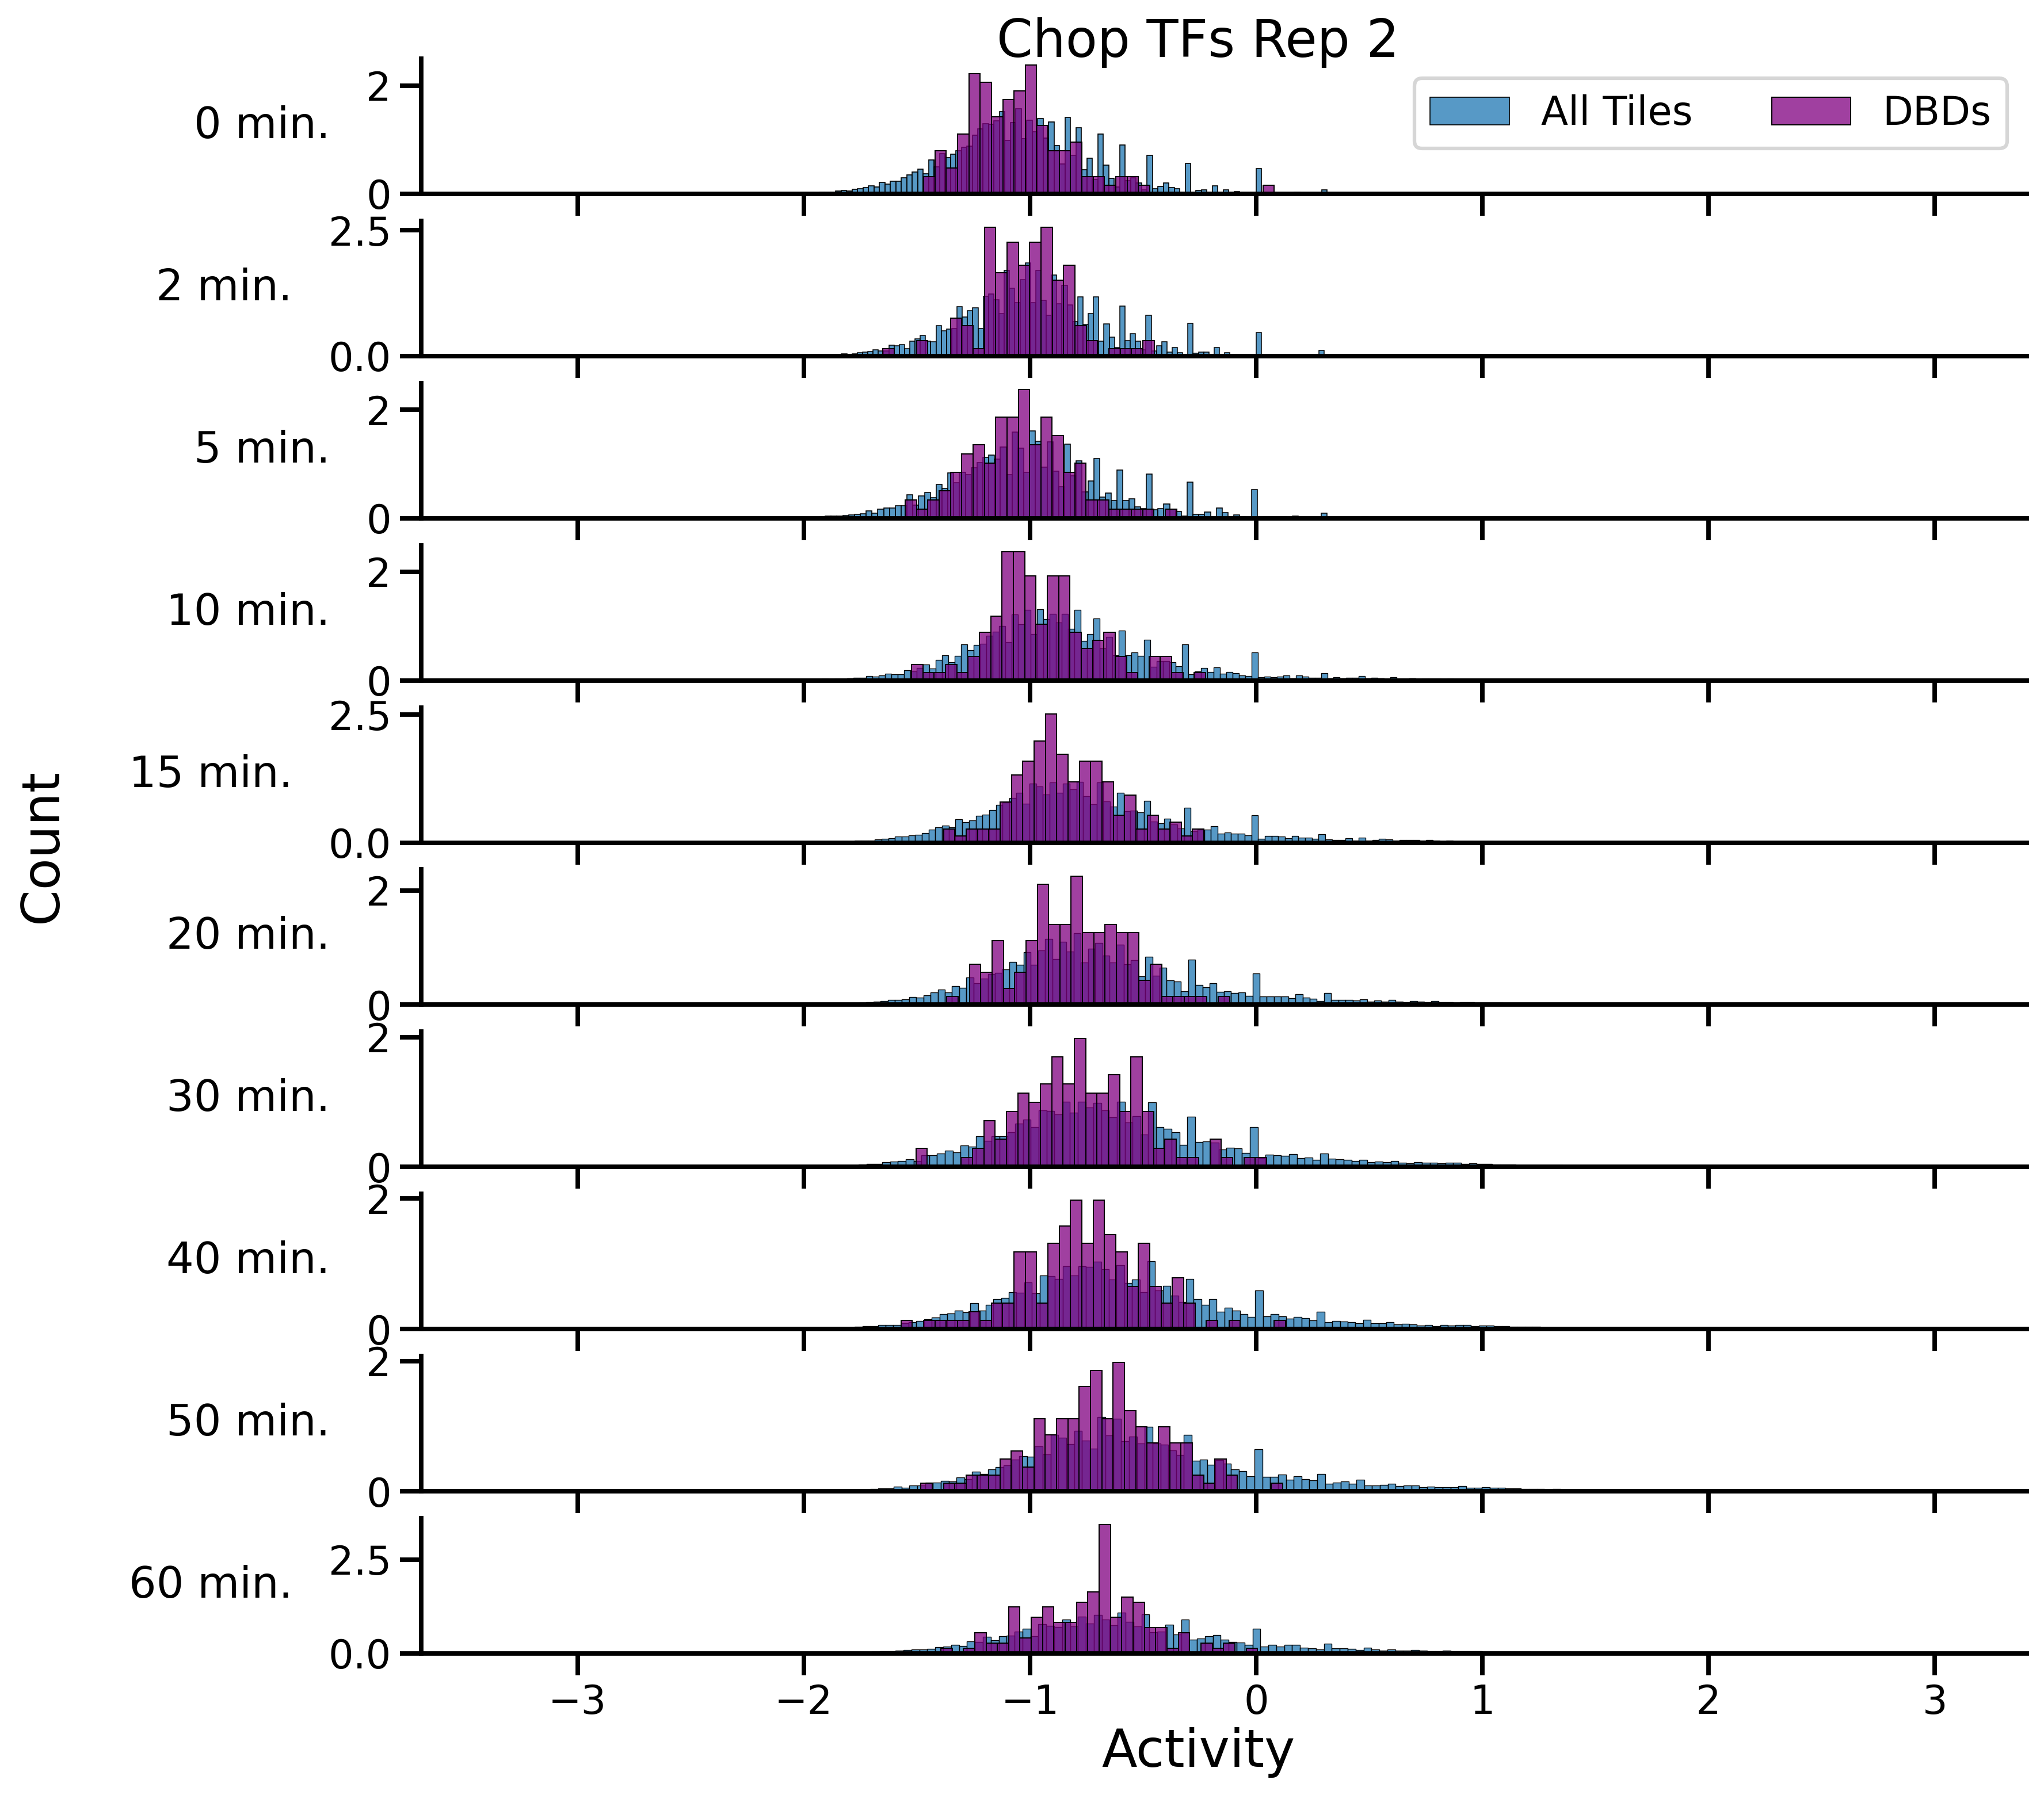

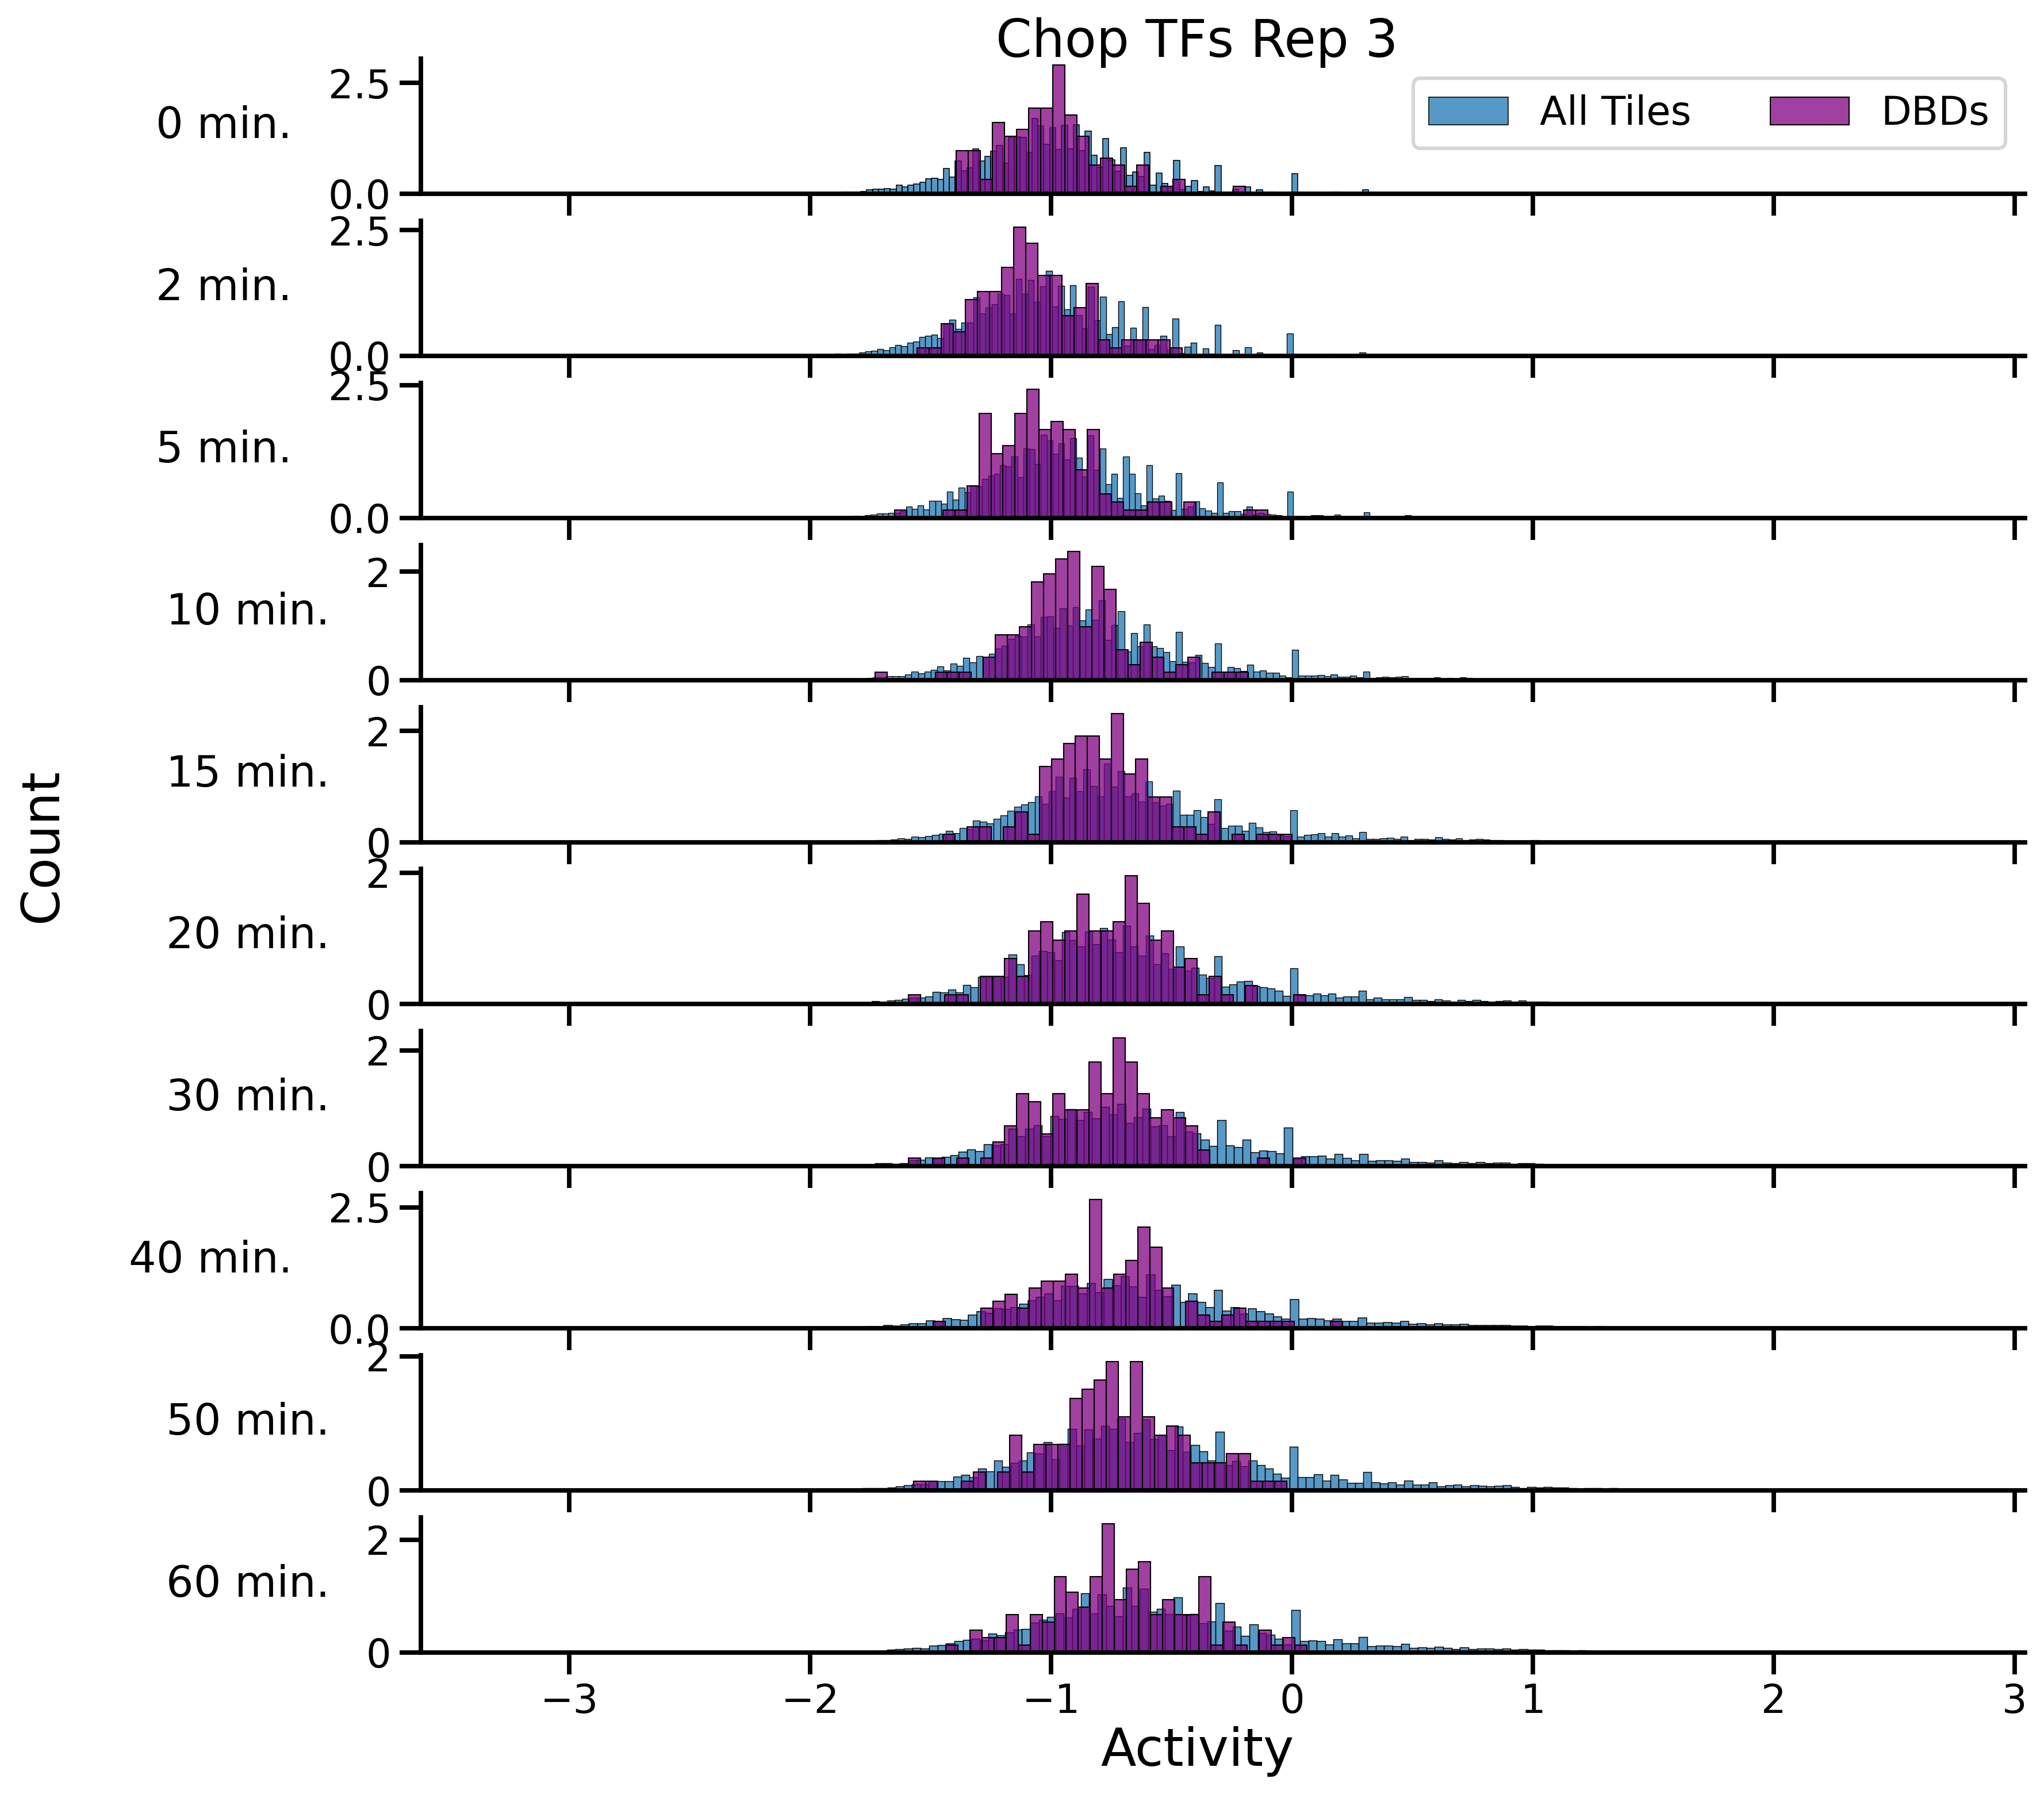

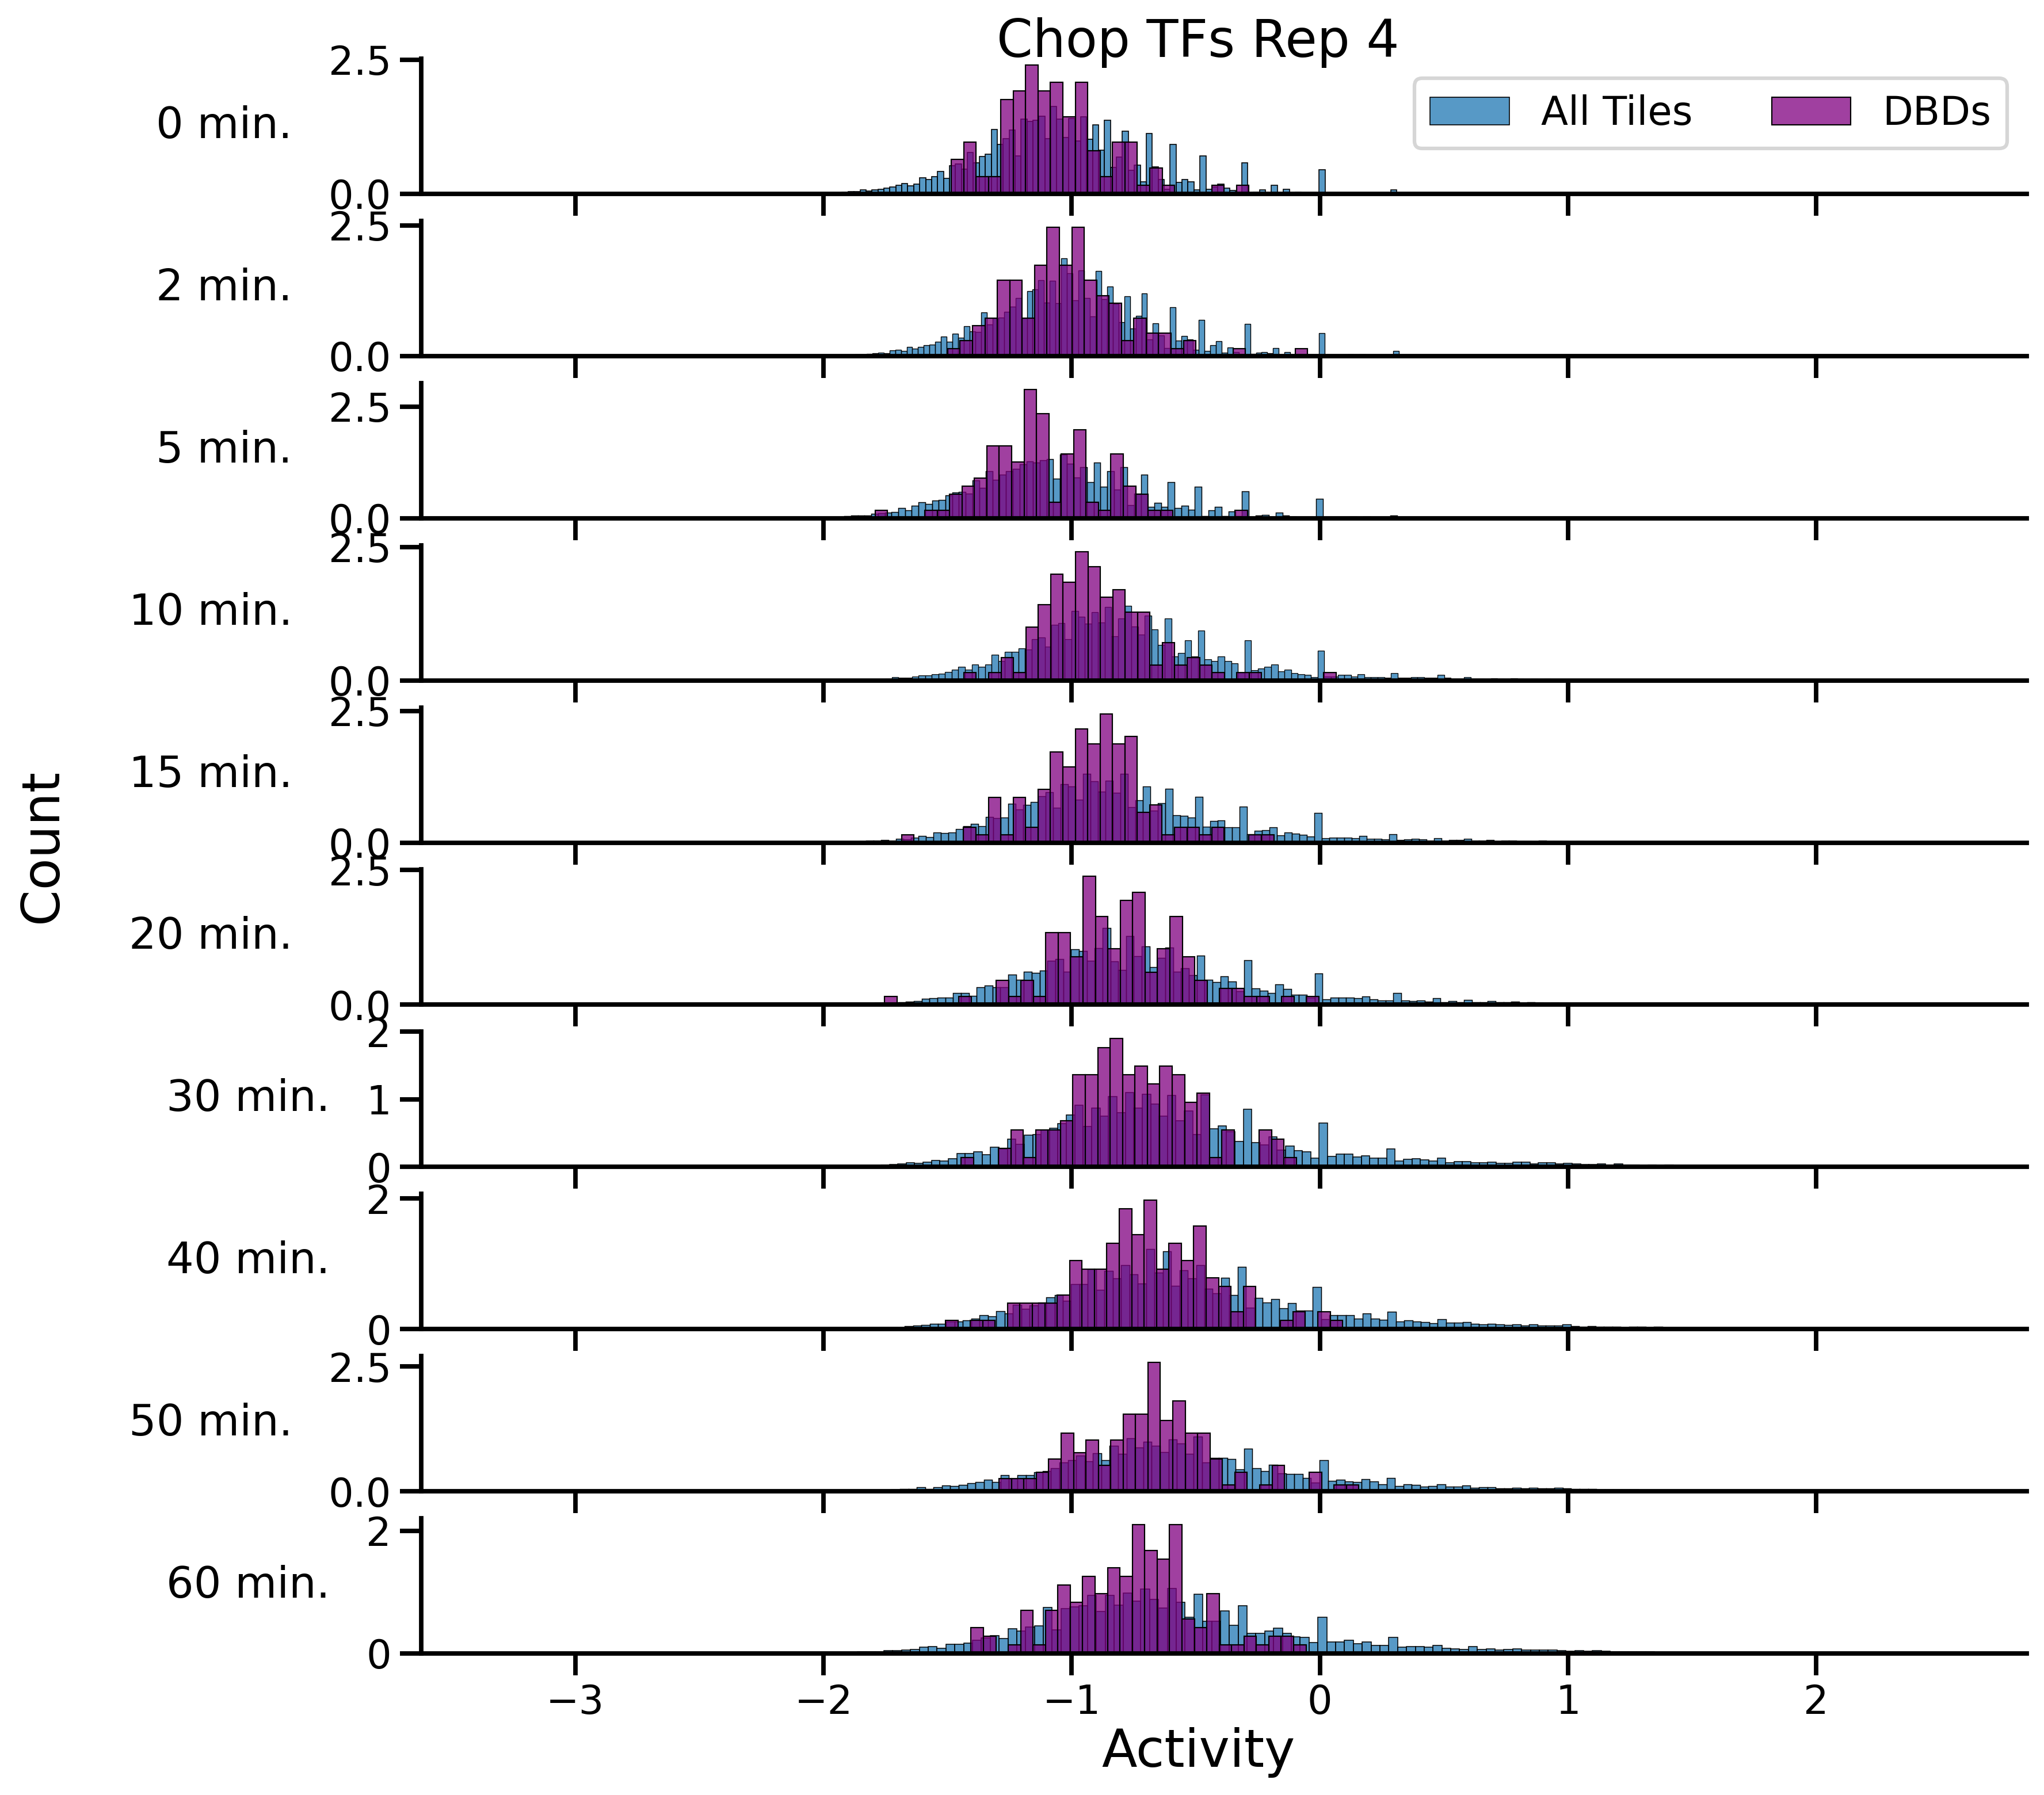

In [170]:
for rep in [2,3,4]:
    fig,axs = time_normalization_helpers.plot_hists_over_time(activities_per_bc[activities_per_bc["rep"] == rep])

    times = np.array(ad_df["time"].drop_duplicates().sort_values())
        
    for i in tqdm(range(len(times))):
        sns.histplot(data = dbd_tiles[(dbd_tiles["rep"] == rep) & (dbd_tiles["time"] == times[i])], 
                     x = "activity_directional_mean", 
                     ax = axs[i],
                    stat = 'density', color = 'purple', binwidth = 0.05, label = "DBDs")
        axs[i].set_xlabel("")
    
    axs[0].legend(ncols = 2)
    
    fig.suptitle(f"Chop TFs Rep {rep}", y = 0.9)